# Training the voice recognition model.

I am teaching the model to distinguish between people’s voices, as well as to understand the voice of its creator. That is, me!

Training on the device: cuda:0
Start of training TinyECAPA (Scratch)...
Epoch [01/25] | Loss: 7.0361 | Val EER: 17.50%
Epoch [05/25] | Loss: 3.2622 | Val EER: 5.00%
Epoch [10/25] | Loss: 1.5218 | Val EER: 3.00%
Epoch [15/25] | Loss: 0.8698 | Val EER: 0.00%
Epoch [20/25] | Loss: 0.6854 | Val EER: 0.00%
Epoch [25/25] | Loss: 0.5870 | Val EER: 0.00%


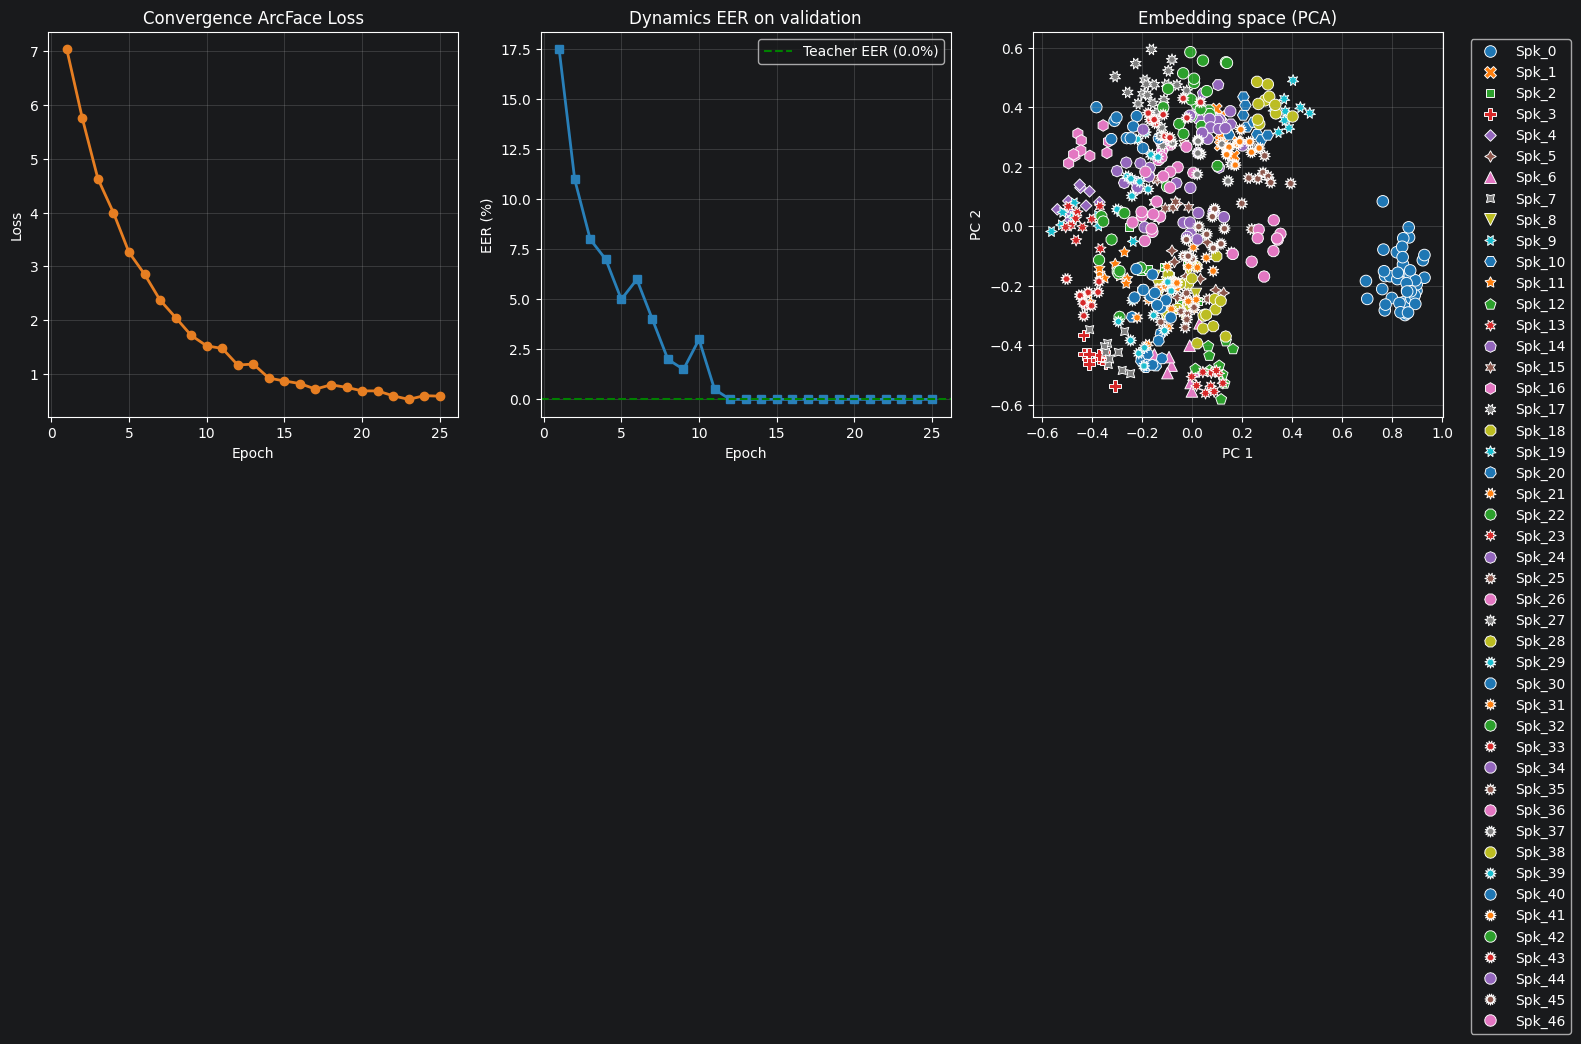

In [1]:
import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from models.student.tiny_ecapa import TinyECAPA
from src.dataset import VoiceprintDataset, MelSpectrogramExtractor
from src.losses import ArcMarginProduct
import torchaudio

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Training on the device: {device}")

train_dataset = VoiceprintDataset("data/manifest/train.csv", segment_length=32000, augment=True)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)

# Test pairs
val_pairs = []
with open("data/manifest/val_pairs.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        val_pairs.append((r["path1"], r["path2"], int(r["label"])))

# Initialization of the model & optimizer
student = TinyECAPA(in_features=80, channels=128, emb_dim=192).to(device)
num_classes = len(set(sample[1] for sample in train_dataset.samples))
arcface = ArcMarginProduct(in_features=192, out_features=num_classes, s=15.0, m=0.25).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    list(student.parameters()) + list(arcface.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)

extractor = MelSpectrogramExtractor()

def get_student_emb(path):
    sig, fs = torchaudio.load(path)
    if sig.shape[0] > 1:
        sig = torch.mean(sig, dim=0, keepdim=True)
    if fs != 16000:
        sig = torchaudio.transforms.Resample(fs, 16000)(sig)
        fs = 16000
    mel = extractor(sig, fs).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = student(mel).squeeze().cpu().numpy()
    return emb

def compute_val_eer():
    cache = {}
    scores = []
    labels = []
    for p1, p2, label in val_pairs:
        if p1 not in cache:
            cache[p1] = get_student_emb(p1)
        if p2 not in cache:
            cache[p2] = get_student_emb(p2)
        scores.append(float(np.dot(cache[p1], cache[p2])))
        labels.append(label)

    scores = np.array(scores)
    labels = np.array(labels)
    thresholds = np.linspace(-0.2, 1.0, 500)
    far = [np.mean(scores[labels == 0] >= t) for t in thresholds]
    frr = [np.mean(scores[labels == 1] < t) for t in thresholds]
    idx = np.nanargmin(np.abs(np.array(far) - np.array(frr)))
    return (far[idx] + frr[idx]) / 2.0

EPOCHS = 25
loss_history = []
eer_history = []

print("Start of training TinyECAPA (Scratch)...")
for epoch in range(1, EPOCHS + 1):
    student.train()
    arcface.train()
    epoch_losses = []

    for mels, spk_ids in train_loader:
        mels = mels.to(device)
        spk_ids = spk_ids.to(device)

        optimizer.zero_grad()
        embeddings = student(mels)
        outputs = arcface(embeddings, spk_ids)
        loss = criterion(outputs, spk_ids)

        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    scheduler.step()

    student.eval()
    val_eer = compute_val_eer()
    avg_loss = np.mean(epoch_losses)

    loss_history.append(avg_loss)
    eer_history.append(val_eer * 100)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Loss: {avg_loss:.4f} | Val EER: {val_eer * 100:.2f}%")

# weights baseline
os.makedirs("models/student", exist_ok=True)
torch.save(student.state_dict(), "models/student/tiny_ecapa_scratch.pth")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, EPOCHS + 1), loss_history, color="#e67e22", lw=2, marker="o")
axes[0].set_title("Convergence ArcFace Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), eer_history, color="#2980b9", lw=2, marker="s")
axes[1].axhline(0.0, color="green", linestyle="--", label="Teacher EER (0.0%)")
axes[1].set_title("Dynamics EER on validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("EER (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 2D Visualization
all_embs = []
all_labels = []
with open("data/manifest/train.csv", "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        all_embs.append(get_student_emb(row["path"]))
        all_labels.append(f"Spk_{row['speaker_id']}")

pca = PCA(n_components=2)
reduced = pca.fit_transform(np.array(all_embs))

sns.scatterplot(
    x=reduced[:, 0], y=reduced[:, 1],
    hue=all_labels, style=all_labels,
    palette="tab10", s=70, ax=axes[2]
)
axes[2].set_title("Embedding space (PCA)")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The model trained from scratch showed good results. However, overfitting is noticeable at the final stage. It is necessary to distill the knowledge from the teacher’s model to my model.